Configuração do Ambiente e Regras Fiscais (ICMS PE 20,5%)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#1. Cria ou carrega o banco de dados (CSV)
def iniciar_banco():
    colunas = ['ID', 'Produto', 'Fornecedor', 'Coleção', 'Custo', 'Marktup', 'Preço_Venda', 'NCM', 'ICMS_PE']
    try:
        return pd.read_csv('estoque_fiscal.csv')
    except:
        return pd.DataFrame(columns=colunas)

#2. Motor Fiscal: Calcula preço final e o imposto (20,5% de PE)
def calcular_financeiro(custo, marktup):
    preco_venda = custo * marktup
    icms = preco_venda * 0.205
    return round(preco_venda, 2), round(icms, 2)

#3. Validador: Garante que o NCM tenha 8 dígitos numéricos
def ncm_valido(ncm):
    return len(str(ncm)) == 8 and str(ncm) .isdigit()

estoque = iniciar_banco()
print("Sistema inicializando e regras fiscais aplicadas!")



Sistema inicializando e regras fiscais aplicadas!


In [6]:
def cadastrar(df, nome, fornecedor, colecao, custo, marktup, ncm):
    if not ncm_valido(ncm):
        print(f" Erro: NCM {ncm} inválido. O produto {nome} não foi cadastrado.")
        return df

    venda, imposto = calcular_financeiro(custo, marktup)

    # Criando o dicionário com os dados do novo produto
    novo = {
        'ID': len(df) + 1,
        'Produto': nome.upper(),
        'Fornecedor': fornecedor.upper(),
        'Coleção': custo,
        'Marktup': marktup,
        'Preço_Venda': venda,
        'NCM': ncm,
        'ICMS_PE': imposto
    }

    # Adiciona ao DataFrame e salva no arquivo CSV
    df = pd.concat([df, pd.DataFrame([novo])], ignore_index=True)
    df.to_csv('estoque_fiscal.csv', index=False)
    print(f"✅ {nome.upper()} cadastrado com sucesso! | Preço de Venda: {venda} | ICMS (PE): R$ {imposto}")
    return df

# Agora vamos "alimentar" o sistema com alguns produtos
estoque = cadastrar(estoque, "Blusa Viscolinho Botões", "Estrela do Sul", "Verão 2026", 45.0, 2.2, "62063000" )
estoque = cadastrar(estoque, "Calça Pantalona Viscose", "Moda PE", "Verão 2026", 60.0, 2.5, "62046300")
estoque = cadastrar(estoque, "Blazer Linho", "Alfaitaria Recife", "Outono 2026", 120.0, 3.0, "62043200")


✅ BLUSA VISCOLINHO BOTÕES cadastrado com sucesso! | Preço de Venda: 99.0 | ICMS (PE): R$ 20.3
✅ CALÇA PANTALONA VISCOSE cadastrado com sucesso! | Preço de Venda: 150.0 | ICMS (PE): R$ 30.75
✅ BLAZER LINHO cadastrado com sucesso! | Preço de Venda: 360.0 | ICMS (PE): R$ 73.8


In [7]:
def gerar_manifesto(df, lista_ids):
    # Filtra no banco de dados apenas os IDs que você escolheu
    carga = df[df['ID'].isin(lista_ids)]

    if carga.empty:
        print("❌ Nenhum item encontrado para esses IDs. Verifique se os IDs estão corretos.")
        return

    # Cálculos para o relatório
    total_venda = carga['Preço_Venda'].sum()
    total_itens = len(carga)
    nomes_produtos = ",".join(carga['Produto'].tolist())

    print("-" * 50)
    print("🚚  MANIFESTO DE CARGA (SIMULADO MDF-e)  🚚")
    print("-" * 50)
    print(f"STATUS: Pronto para Despacho")
    print(f"QUANTIDADE DE VOLUMES: {total_itens}")
    print(f"VALOR TOTAL DA CARGA: R$ {total_venda:.2f}")
    print(f"ITENS INCLUÍDOS: {nomes_produtos}")
    print("-" * 50)
    print("✅ Logística processada com sucesso!")

# TESTE PRÁTICO: Gerando o manifesto para os produtos de ID 1 e 2
gerar_manifesto(estoque, [1, 2])


--------------------------------------------------
🚚  MANIFESTO DE CARGA (SIMULADO MDF-e)  🚚
--------------------------------------------------
STATUS: Pronto para Despacho
QUANTIDADE DE VOLUMES: 2
VALOR TOTAL DA CARGA: R$ 249.00
ITENS INCLUÍDOS: BLUSA VISCOLINHO BOTÕES,CALÇA PANTALONA VISCOSE
--------------------------------------------------
✅ Logística processada com sucesso!


Dashboard de Business Intelligence para Tomada de Decisão


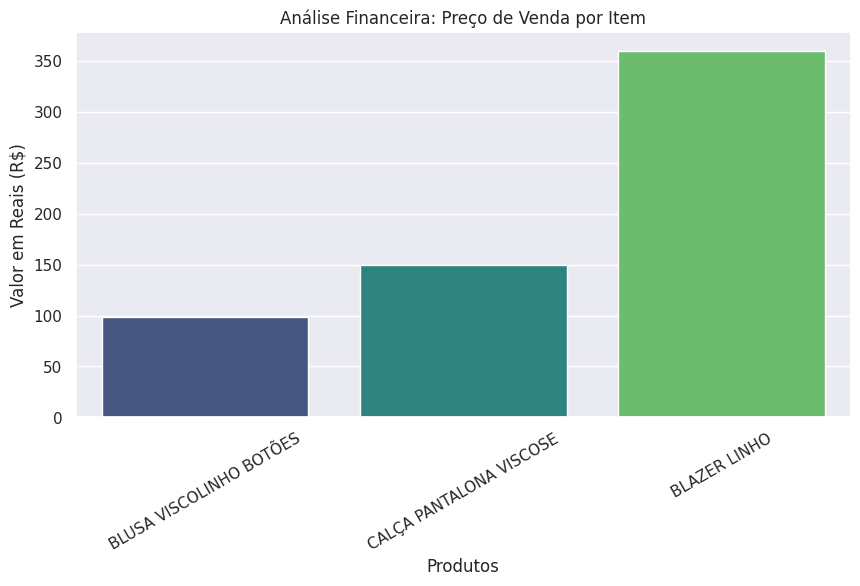

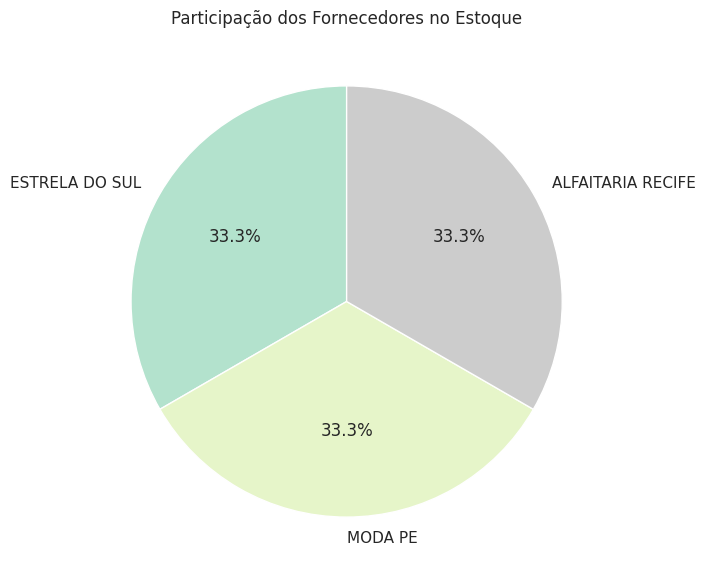

--- RELATÓRIO FINAL DE ESTOQUE ---


,ID,Produto,Fornecedor,Coleção,Custo,Marktup,Preço_Venda,NCM,ICMS_PE
0,1,BLUSA VISCOLINHO BOTÕES,ESTRELA DO SUL,45.0,NaN,2.2,99.0,62063000,20.30
1,2,CALÇA PANTALONA VISCOSE,MODA PE,60.0,NaN,2.5,150.0,62046300,30.75
2,3,BLAZER LINHO,ALFAITARIA RECIFE,120.0,NaN,3.0,360.0,62043200,73.80
3,4,BLUSA VISCOLINHO BOTÕES,ESTRELA DO SUL,45.0,NaN,2.2,99.0,62063000,20.30
4,5,CALÇA PANTALONA VISCOSE,MODA PE,60.0,NaN,2.5,150.0,62046300,30.75
5,6,BLAZER LINHO,ALFAITARIA RECIFE,120.0,NaN,3.0,360.0,62043200,73.80


In [8]:
# 1. Definindo o visual dos gráficos
sns.set_theme(style="darkgrid")

# 2. Criando o Gráfico de Barras (Preços de Venda)
plt.figure(figsize=(10, 5))
# Aqui o Python liga a coluna 'Produto' com a 'Preço_Venda'
sns.barplot(x='Produto', y='Preço_Venda', data=estoque, hue='Produto', palette='viridis', legend=False)

plt.title('Análise Financeira: Preço de Venda por Item')
plt.xlabel('Produtos')
plt.ylabel('Valor em Reais (R$)')
plt.xticks(rotation=30) # Inclina o texto para não amontoar
plt.show()

# 3 Criando o Gráfico de Pizza (Fornecedores)
plt.figure(figsize=(7, 7))
estoque['Fornecedor'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel2')

plt.title('Participação dos Fornecedores no Estoque')
plt.ylabel('') # Remove a etiqueta lateral para ficar limpo
plt.show()

# Mostra as primeiras linhas do seu banco de dados final
print("--- RELATÓRIO FINAL DE ESTOQUE ---")
display(estoque)


In [9]:
def analisar_cliente(segmento, faturamento_mensal):
  #Regra de negócio: Foco em lojas de MODA com faturamento alto
  if segmento.lower() == 'moda' and faturamento_mensal >= 10000:
      return "🎯 CLIENTE IDEAL (ICP) - Prioridade Total!"
  elif segmento.lower() == 'moda':
      return "📈 Lead em Crescimento - Manter contato."
  else:
      return "⏩ Fora do Perfil - Não focar agora."

# Testando a lógica com um exemplo prático
resultado = analisar_cliente('Moda', 15000)
print(f"Resultado da Prospecção: {resultado}")

Resultado da Prospecção: 🎯 CLIENTE IDEAL (ICP) - Prioridade Total!
